## Data Overview

In [1]:
#importing basic libraries usually used for the data analysis projects
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [2]:
#dataset loading
df = pd.read_csv('C:/Users/DELL/Bank-Personal-Loan.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [5]:
#checking for null values 
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [6]:
data = df.copy()
data = data.drop(['ID','ZIP Code'],axis=1)
data.head(3)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0


In [7]:
data.shape

(5000, 12)

In [8]:
for i in data.columns:
    print(i)
    print(data[i].unique())

Age
[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
Experience
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
Income
[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 151 199 224 218]
Family
[4 3 1 2]
CCAvg
[ 1.6   1.5   1

In [9]:
data['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43], dtype=int64)

In [10]:
#cleaned the negative values to postive values, since experience cannot be negative
data['Experience'] = data['Experience'].abs()
data['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, 34,  0, 38, 40, 33,  4, 42, 43], dtype=int64)

In [11]:
#box plot function
def box(x):
    plt.figure(figsize=(3,2))
    sns.boxplot(data[x])
    plt.xlabel(x)
    plt.title(x)
    return plt.show()

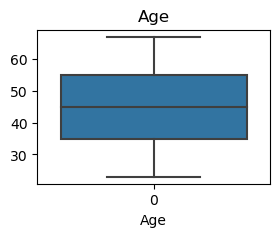

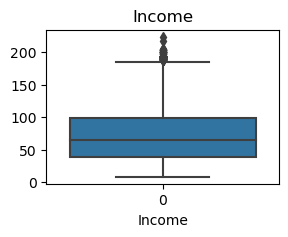

In [12]:
#box plot for each columns
box('Age')
box('Income')

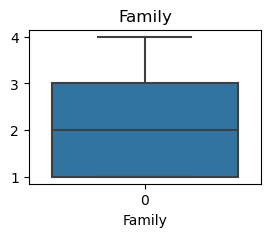

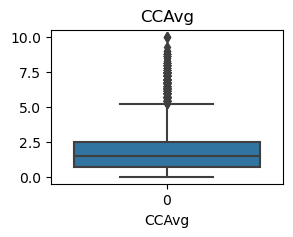

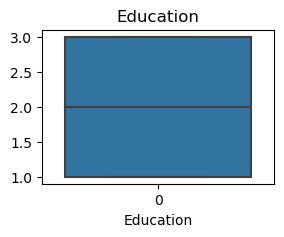

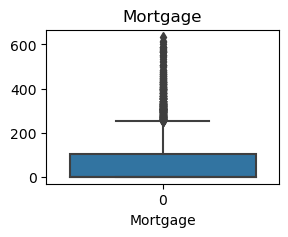

In [13]:
box('Family')
box('CCAvg')
box('Education')
box('Mortgage')

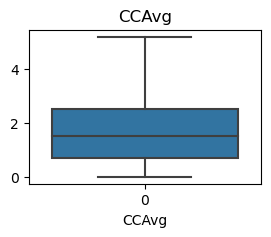

In [14]:
#CCAvg outlier removal 
Q3 = data['CCAvg'].quantile(0.75)
Q1 = data['CCAvg'].quantile(0.25)
IQR = Q3 - Q1
upper_bound_IQR = Q3 + 1.5*IQR
lower_bound_IQR = Q1 - 1.5*IQR

mean = data['CCAvg'].mean()
std = data['CCAvg'].std()
upper_bound_zscore = mean + 3*std
lower_bound_zcore = mean - 3*std

lower_bound = min(lower_bound_zcore,lower_bound_IQR)
upper_bound = max(upper_bound_zscore,upper_bound_IQR)

data['CCAvg'] = data['CCAvg'].clip(lower = lower_bound_IQR, upper = upper_bound_IQR)
box('CCAvg')

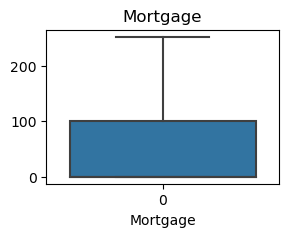

In [15]:
#Mortgage outlier removal 
Q3 = data['Mortgage'].quantile(0.75)
Q1 = data['Mortgage'].quantile(0.25)
IQR = Q3 - Q1
upper_bound_IQR = Q3 + 1.5*IQR
lower_bound_IQR = Q1 - 1.5*IQR

mean = data['Mortgage'].mean()
std = data['Mortgage'].std()
upper_bound_zscore = mean + 3*std
lower_bound_zcore = mean - 3*std

lower_bound = min(lower_bound_zcore,lower_bound_IQR)
upper_bound = max(upper_bound_zscore,upper_bound_IQR)

data['Mortgage'] = data['Mortgage'].clip(lower = lower_bound_IQR, upper = upper_bound_IQR)
box('Mortgage')

## Exploratory Data Analysis (EDA)

In [16]:
#getting histogram for the column
def histogram(col):
    plt.figure(figsize=(4,3))
    plt.hist(data[col],linewidth=1,edgecolor='k')
    plt.title(f'Distribution of {col}')
    plt.show()

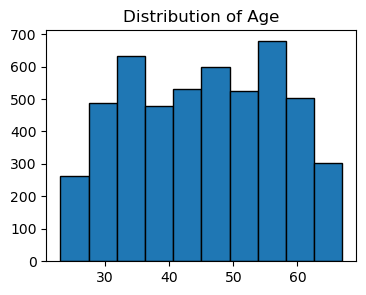

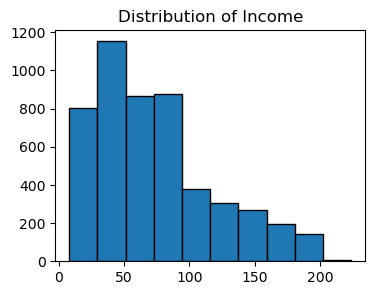

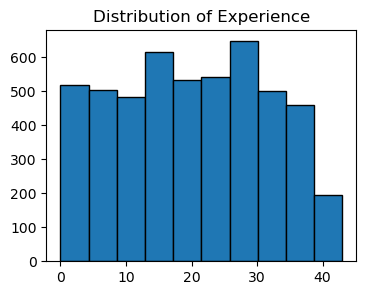

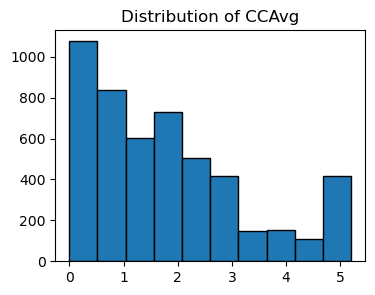

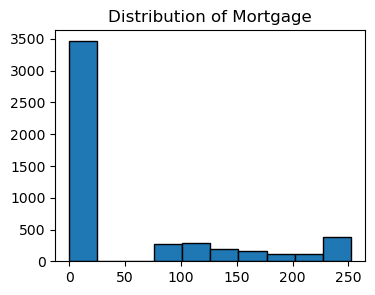

In [17]:
#representing the distribution by histogram for numerical columns
num_cols = ['Age','Income','Experience','CCAvg','Mortgage']
for i in num_cols:
    histogram(i)

In [18]:
#user-defined function for pie chart
def pie_chart(col):
    plt.pie(data[col].value_counts(),labels=list(data[col].value_counts().index),autopct='%.2f%%',
           wedgeprops={'edgecolor':'k','linewidth':0.5})
    plt.title(f'Distribution of {col}')
    plt.show()

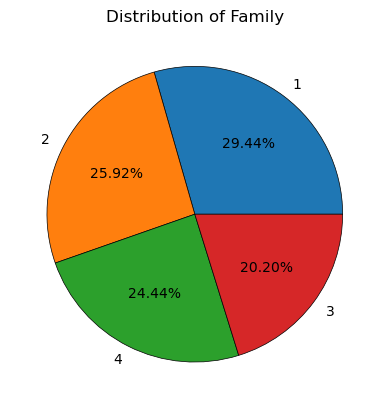

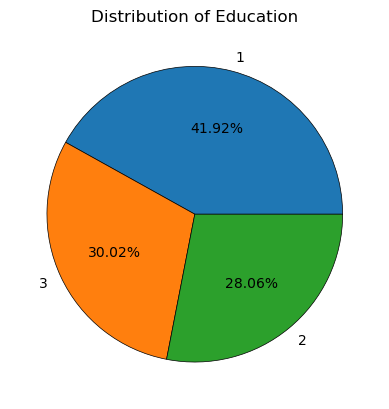

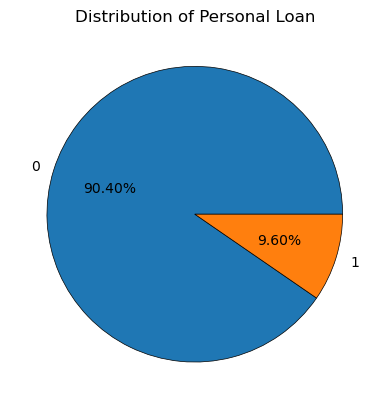

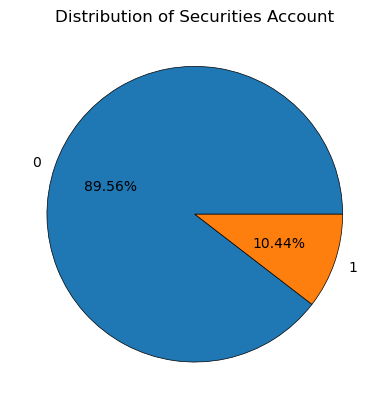

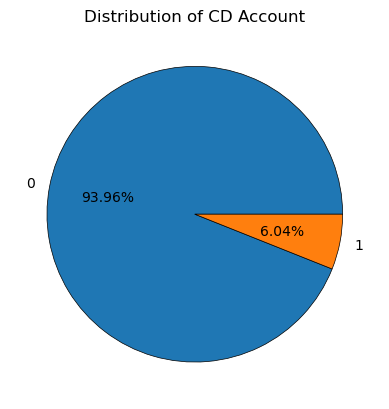

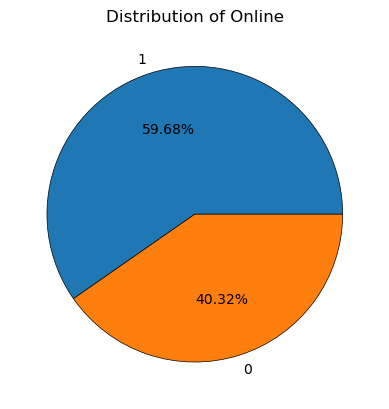

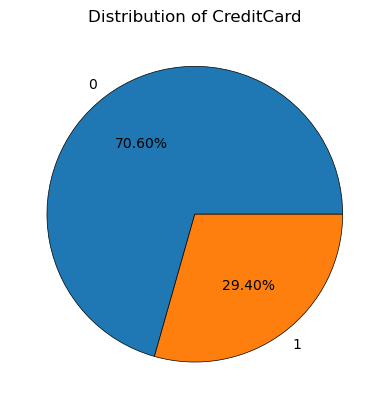

In [19]:
#using the pie chart for the categorical columns 
cat_cols = ['Family','Education','Personal Loan','Securities Account','CD Account','Online','CreditCard']
for i in cat_cols:
    pie_chart(i)

## Multicollinearity Check

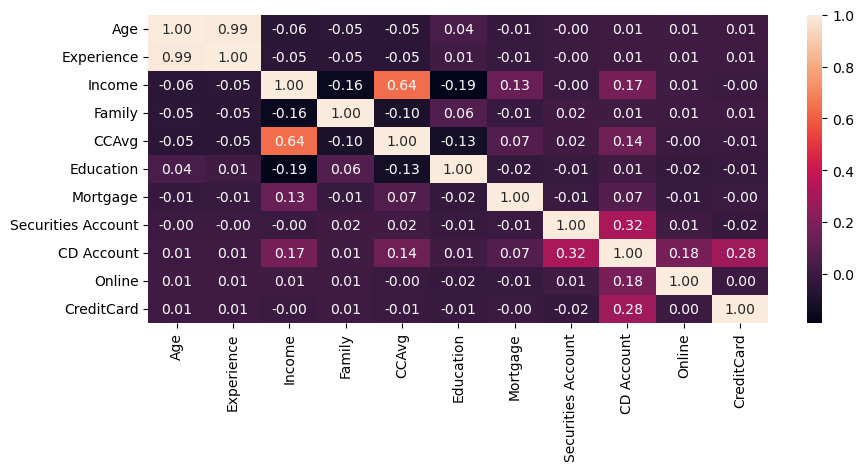

In [20]:
#check for multicollinearity
ind_var = data.drop('Personal Loan',axis='columns')
plt.figure(figsize=(10,4))
sns.heatmap(ind_var.corr(),annot=True,fmt='.2f' );

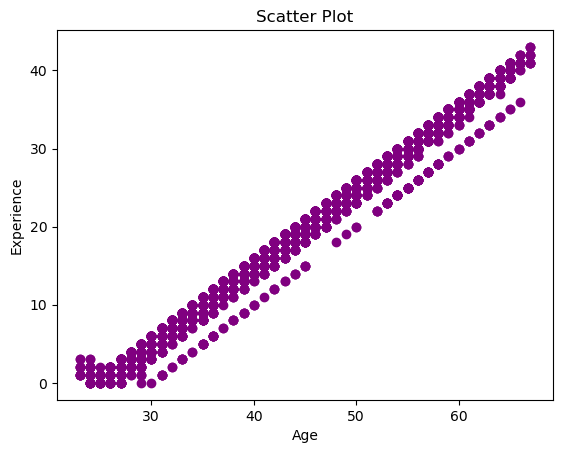

In [21]:
#scatter plot for age and experience
plt.scatter(data['Age'],data['Experience'],color='purple')
plt.title('Scatter Plot')
plt.xlabel('Age')
plt.ylabel('Experience')
plt.show()

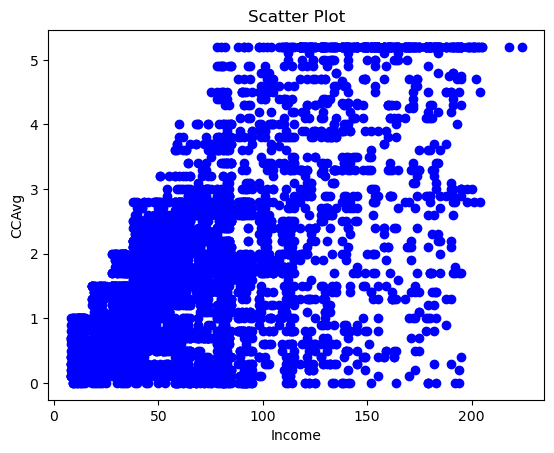

In [22]:
#scatter plot for age and experience
plt.scatter(data['Income'],data['CCAvg'],color='blue')
plt.title('Scatter Plot')
plt.xlabel('Income')
plt.ylabel('CCAvg')
plt.show()

In [23]:
#checking multicollinearity by means variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

coll_data = data[['Age','Experience']]
const_val = add_constant(coll_data)
vif_data = pd.DataFrame()
vif_data['Features'] = const_val.columns 
vif_data['VIF'] = [variance_inflation_factor(const_val.values,i) for i in range(const_val.shape[1])]
vif_data

,Features,VIF
0,const,408.812824
1,Age,83.455412
2,Experience,83.455412


In [24]:
#checking multicollinearity by means variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

coll_data = data[['Income','CCAvg']]
const_val = add_constant(coll_data)
vif_data = pd.DataFrame()
vif_data['Features'] = const_val.columns 
vif_data['VIF'] = [variance_inflation_factor(const_val.values,i) for i in range(const_val.shape[1])]
vif_data

,Features,VIF
0,const,3.664897
1,Income,1.686499
2,CCAvg,1.686499


In [25]:
data = data.drop('Age',axis='columns')
data.columns

Index(['Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Personal Loan', 'Securities Account', 'CD Account', 'Online',
       'CreditCard'],
      dtype='object')

## Model Building

In [26]:
#split the target and the independent variable
y = data['Personal Loan']
x = data.drop('Personal Loan',axis=1)
print(x.columns)
print(y.shape)

Index(['Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')
(5000,)


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print('X train and test sets are ',x_train.shape , x_test.shape)
print('Y train and test sets are ',y_train.shape, y_test.shape)

X train and test sets are  (3500, 10) (1500, 10)
Y train and test sets are  (3500,) (1500,)


In [28]:
y.value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

In [29]:
#using the scaling approach
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_train_trans = ss.fit_transform(x_train)
x_test_trans = ss.fit_transform(x_test)

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l2',C=1.0,class_weight='balanced') #l2 reduces impact of multicollinearity by shrinking coefficients 
lr

LogisticRegression(class_weight='balanced')

In [31]:
model = lr.fit(x_train_trans,y_train)
model

LogisticRegression(class_weight='balanced')

## Model Evaluation

In [32]:
y_pred_proba = lr.predict_proba(x_test_trans)

from sklearn.metrics import roc_curve, auc
for threshold in np.arange(0,1,0.05):
    ypred = (y_pred_proba[:,1]>=threshold).astype(int)
    fpr,tpr,_ = roc_curve(y_test,ypred)
    auc_value = auc(fpr,tpr)
    print('Threshold of %.2f gives auc = %.4f'%(threshold,auc_value))

Threshold of 0.00 gives auc = 0.5000
Threshold of 0.05 gives auc = 0.7684
Threshold of 0.10 gives auc = 0.8246
Threshold of 0.15 gives auc = 0.8544
Threshold of 0.20 gives auc = 0.8756
Threshold of 0.25 gives auc = 0.8787
Threshold of 0.30 gives auc = 0.8884
Threshold of 0.35 gives auc = 0.8929
Threshold of 0.40 gives auc = 0.8972
Threshold of 0.45 gives auc = 0.8994
Threshold of 0.50 gives auc = 0.9052
Threshold of 0.55 gives auc = 0.9115
Threshold of 0.60 gives auc = 0.9118
Threshold of 0.65 gives auc = 0.9035
Threshold of 0.70 gives auc = 0.8988
Threshold of 0.75 gives auc = 0.8877
Threshold of 0.80 gives auc = 0.8759
Threshold of 0.85 gives auc = 0.8592
Threshold of 0.90 gives auc = 0.8131
Threshold of 0.95 gives auc = 0.7419


In [33]:
#best threshold is 0.60
threshold = 0.60
y_pred = (y_pred_proba[:,1]>=threshold).astype(int)
y_pred

array([0, 1, 0, ..., 0, 0, 1])

In [34]:
from sklearn.metrics import accuracy_score,roc_curve,confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy of the model is %.4f'%accuracy )


Accuracy of the model is 0.9227


In [35]:
fpr,tpr,_ = roc_curve(y_test,y_pred)
auc_value = auc(fpr,tpr)
print('AUC of the model is %.4f'%auc_value)

AUC of the model is 0.9118


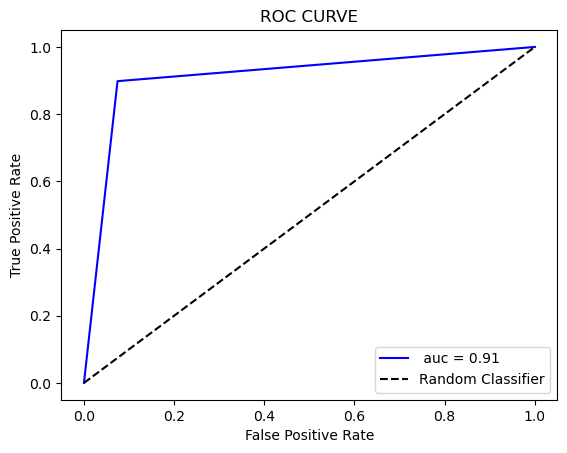

In [36]:
#roc - auc curve code
plt.plot(fpr,tpr,color='blue',label=f" auc = {auc_value:.2f}")
plt.plot([0, 1], [0, 1],color='black',linestyle='--',label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

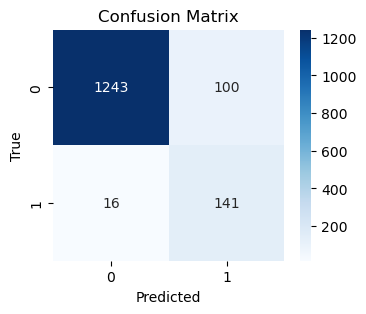

In [37]:
#confusion matrix of the model
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm,square=True,annot=True,fmt='.0f',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [38]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1343
           1       0.59      0.90      0.71       157

    accuracy                           0.92      1500
   macro avg       0.79      0.91      0.83      1500
weighted avg       0.95      0.92      0.93      1500



## Determining Crucial Features 

In [39]:
print('Intercept',np.round(lr.intercept_,4))
print('Coefficient',np.round(lr.coef_,4))

Intercept [-2.3954]
Coefficient [[ 0.0712  2.2609  0.6411  0.5909  1.0415  0.0559 -0.3213  0.8509 -0.3191
  -0.5043]]


In [40]:
beta = lr.coef_
odd_ratios = np.exp(beta)
variables = x_train.columns 
print(odd_ratios)

[[1.07376548 9.59181219 1.89865313 1.80554765 2.83335435 1.05750372
  0.72521985 2.34168181 0.72680714 0.60392783]]


In [41]:
from scipy.stats import norm
from numpy.linalg import inv


# Step 1: Compute the predicted probabilities
p = model.predict_proba(x_train_trans)[:, 1]
X_design = np.hstack([np.ones((x_train_trans.shape[0], 1)), x_train_trans])  # Add intercept

# Step 2: Compute the variance-covariance matrix
V = np.diag(p * (1 - p))
cov_matrix = inv(X_design.T @ V @ X_design)

# Step 3: Standard errors
se = np.sqrt(np.diag(cov_matrix))

# Step 4: Compute confidence intervals
coef_with_intercept = np.insert(model.coef_.flatten(), 0,model.intercept_)
z = 1.96  # For 95% CI
lower = coef_with_intercept - z * se
upper = coef_with_intercept + z * se

# Step 5: Exponentiate for Odds Ratios
odds_ratioss = np.exp(coef_with_intercept)
lower_or = np.exp(lower)
upper_or = np.exp(upper)

# Display
features = ['Intercept'] + list(x_train.columns)
ci_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': np.round(coef_with_intercept, 4),
    'Odds Ratio': np.round(odds_ratioss, 4),
    'CI Lower': np.round(lower_or, 4),
    'CI Upper': np.round(upper_or, 4)
})

print(ci_df)


               Feature  Coefficient  Odds Ratio  CI Lower  CI Upper
0            Intercept      -2.3954      0.0911    0.0770    0.1079
1           Experience       0.0712      1.0738    0.9519    1.2112
2               Income       2.2609      9.5918    7.8238   11.7594
3               Family       0.6411      1.8987    1.6622    2.1687
4                CCAvg       0.5909      1.8055    1.5804    2.0627
5            Education       1.0415      2.8334    2.4518    3.2743
6             Mortgage       0.0559      1.0575    0.9490    1.1784
7   Securities Account      -0.3213      0.7252    0.6298    0.8351
8           CD Account       0.8509      2.3417    2.0239    2.7093
9               Online      -0.3191      0.7268    0.6434    0.8210
10          CreditCard      -0.5043      0.6039    0.5245    0.6954


### Without the Optimum Cut

In [42]:
y_pred = lr.predict(x_test_trans)

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr,tpr,thresholds = roc_curve(y_test,y_pred)
roc_auc = roc_auc_score(y_test,y_pred)

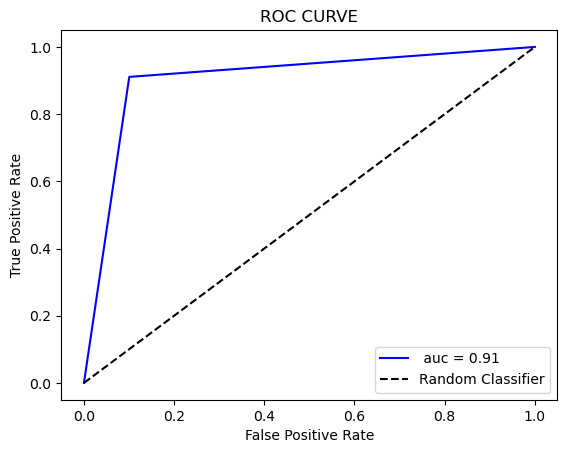

In [44]:
#roc - auc curve code
plt.plot(fpr,tpr,color='blue',label=f" auc = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1],color='black',linestyle='--',label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

In [45]:
threshold = 0.50
y_pred = (y_pred_proba[:,1]>=threshold).astype(int)
y_pred

array([0, 1, 0, ..., 0, 0, 1])

In [46]:
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1343
           1       0.51      0.91      0.66       157

    accuracy                           0.90      1500
   macro avg       0.75      0.91      0.80      1500
weighted avg       0.94      0.90      0.91      1500



In [47]:
accuracy  = accuracy_score(y_test,y_pred)
print('The accuracy of the model without the optimum cut is %.4f'%accuracy)

The accuracy of the model without the optimum cut is 0.9007


In [48]:
auc = roc_auc_score(y_test,y_pred)
print('The auc value of the model without the optimum cut is %.4f'%auc)

The auc value of the model without the optimum cut is 0.9052
